In [ ]:
#requirements.txt

numpy
pandas
seaborn
scikit-learn

In [3]:
#1. Import Libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [5]:
#2. Load Dataset

data = pd.read_csv("Advertising Budget and Sales.csv")
data.head()

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [51]:
#3. Data Cleaning

# Drop Unnecessary Column
#data.drop("Unnamed: 0", axis=1, inplace=True)

# Rename Columns
data.rename(columns={
    "TV Ad Budget ($)": "TV",
    "Radio Ad Budget ($)": "Radio",
    "Newspaper Ad Budget ($)": "Newspaper",
    "Sales ($)": "Sales"
}, inplace=True)


In [45]:
#4. Basic Checks

# Display First 5 Rows
print(data.head())

# Dataset Information
print(data.info())

# Statistical Summary
print(data.describe())

# Check Missing Values
print(data.isnull().sum())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3    9.3
3  151.5   41.3       58.5   18.5
4  180.8   10.8       58.4   12.9
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   29.737000   14.022500
std     85.854236   14.846809   20.347264    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.675000   12.900000
75%    218.825000   36.525000   43.55000

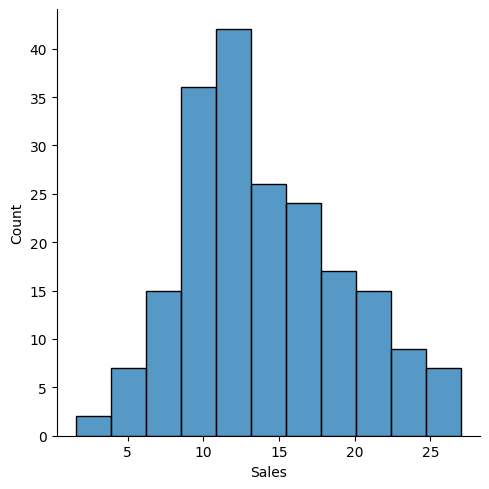

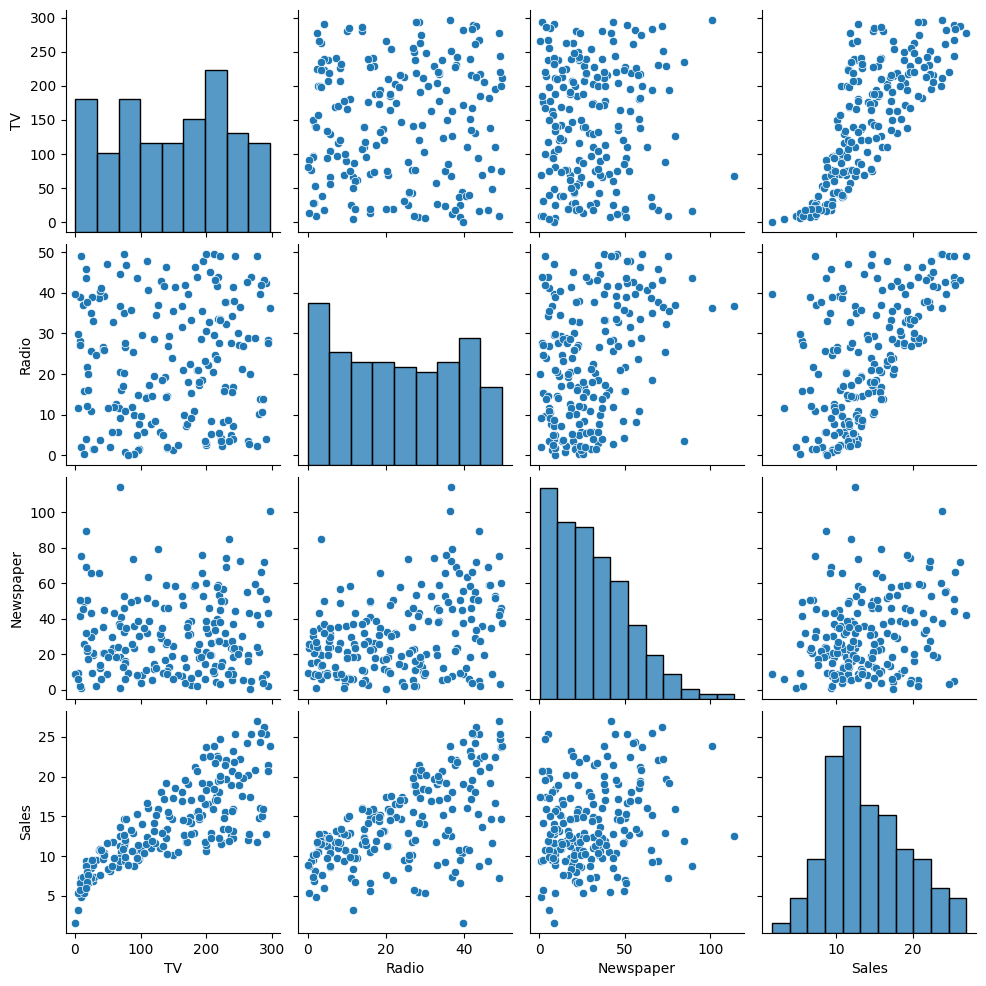

In [13]:
#5. Data Visualization

# Distribution Plot
sns.displot(data['Sales'])
plt.show()

# Pair Plot
sns.pairplot(data)
plt.show()



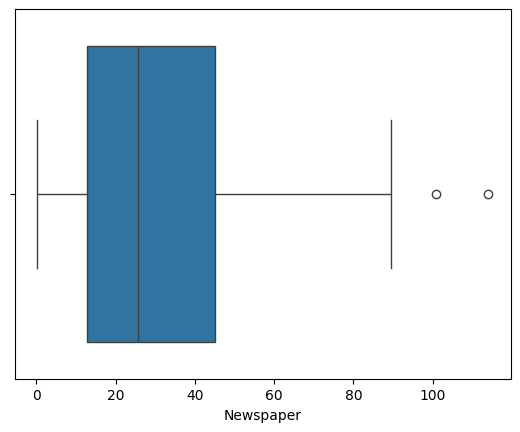

In [15]:
#6. Outlier Detection

# Boxplots
sns.boxplot(x=data.Newspaper)
plt.show()


In [17]:
#7. Outlier Detection using IQR

Q1 = data['Newspaper'].quantile(0.25)
Q3 = data['Newspaper'].quantile(0.75)

IQR = Q3 - Q1

LL = Q1 - 1.5 * IQR
UL = Q3 + 1.5 * IQR

print("Lower Limit:", LL)
print("Upper Limit:", UL)

# Replace Outliers with Median
data.loc[data['Newspaper'] > UL, 'Newspaper'] = data['Newspaper'].median()

# Check Outliers
print(data.loc[(data['Newspaper'] < LL) | (data['Newspaper'] > UL)])


Lower Limit: -35.775000000000006
Upper Limit: 93.625
Empty DataFrame
Columns: [TV, Radio, Newspaper, Sales]
Index: []


                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.048462  0.782224
Radio      0.054809  1.000000   0.343141  0.576223
Newspaper  0.048462  0.343141   1.000000  0.215938
Sales      0.782224  0.576223   0.215938  1.000000


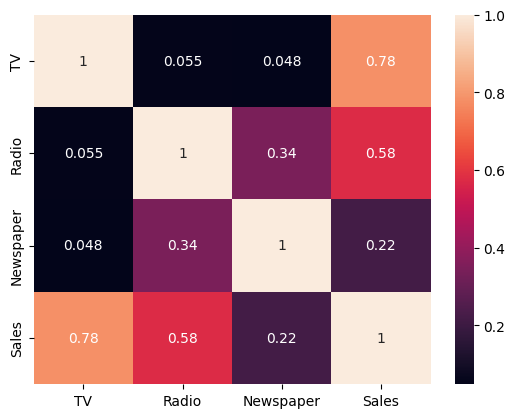

In [35]:
# Correlation Heatmap

corr = data.corr()

print(corr)

sns.heatmap(corr, annot=True)
plt.show()


In [19]:
#8. Split Dataset

x = data.drop("Sales", axis=1)
y = data['Sales']

In [53]:
#9. Train Test Split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.30,
    random_state=42
)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)


x_train shape: (140, 3)
x_test shape: (60, 3)


In [23]:
#10. Model Building


from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [55]:
#11. Prediction

y_pred = model.predict(x_test)

print("Predicted Values:")
print(y_pred)

print("Actual Values:")
print(y_test.values)

# Coefficients and Intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Predicted Values:
[16.56622129 21.19629105 21.56238688 10.88309172 22.22518968 13.35134536
 21.21185118  7.34578696 13.28180806 15.12877207  9.01680516  6.51665134
 14.29096959  8.97062449  9.45350415 12.00297213  8.90727704 16.16669664
 10.29220368 18.74013635 19.76845202 13.16994572 12.50161956 21.53853285
  7.60918067  5.6039813  20.93032937 11.81099992  9.07701481  8.51571567
 12.17849654  9.96882387 21.73711532 12.76276934 18.10871078 20.0949282
 14.27092122 20.94422324 10.84385466  4.37214715  9.51102297 12.41157141
 10.16590644  8.08750962 13.16938565  5.21775327  9.28153513 14.09923882
  8.6836478  11.66408229 15.72277858 11.63536272 13.34338267 11.14597336
  6.33127708  9.75750297  9.41978404 24.26856593  7.69156725 12.15964826]
Actual Values:
[16.9 22.4 21.4  7.3 24.7 12.6 22.3  8.4 11.5 14.9  9.5  8.7 11.9  5.3
 10.3 11.7  5.5 16.6 11.3 18.9 19.7 12.5 10.9 22.2  9.3  8.1 21.7 13.4
 10.6  5.7 10.6 11.3 23.7  8.7 16.1 20.7 11.6 20.8 11.9  6.9 11.  12.8
 10.1  9.7 11.6  7.6 10.

In [57]:
#12. Custom Prediction

sample = pd.DataFrame(
    [[38.2, 3.7, 13.8]],
    columns=x.columns
)

prediction = model.predict(sample)

print("Custom Prediction:", prediction)

Custom Prediction: [5.21775327]


In [59]:
#13. Model Evaluation

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

Mean Squared Error: 3.7716139064161367
Mean Absolute Error: 1.500194066219564
Root Mean Squared Error: 1.9420643414717589
R2 Score: 0.8618689614451722
